<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2024-2/Sesiones/Sesion_13_Bootstraping_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy import optimize
from scipy.stats import norm

In [2]:
def pdf(x, **kywars):
  """
  Generar N distribuciones y su gráfica
  según el diccionario con valores asociados a su media
  y desviacion estandar.
  """
  color = ["g","b","m","r","y"]
  f = {}
  # Generación de N distribuciones normales estadísticas
  for key in kywars:
    fi = stats.norm(loc=kywars[key][0], scale=kywars[key][1])
    f[key] = fi

  # Gráfica de las distribuciones estadísticas
  fig, ax = plt.subplots(1, 1)
  for i, key in enumerate(f):
    ax.plot(x, f[key].pdf(x),f'{color[i]}-', lw=3, alpha=0.6, label=f'pdf {i+1}')
  ax.set_xlabel("x")
  ax.set_ylabel("PDF(X)")
  return "Done", f

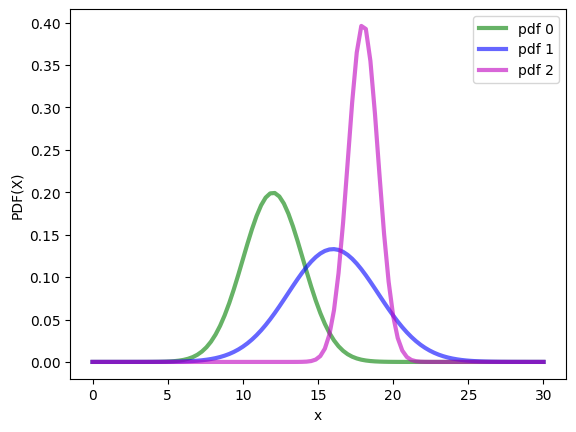

In [3]:
params = {"ms1":[12,2], "ms2":[16,3], "ms3":[18,1]}     # mu, sigma
x = np.linspace(0, 30,100)
_, f = pdf(x,**params)
plt.legend()
plt.show()

Consideremos tres distribuciones estadísticas que representan diferentes tipos de datos. Estas distribuciones corresponden a las longitudes de las aletas de tres tipos distintos de peces marinos:

- La distribución **verde** representa a los peces del **tipo 1**.  
- La distribución **azul** corresponde a los peces del **tipo 2**.  
- La distribución **púrpura** describe a los peces del **tipo 3**.  










In [4]:
# Generamos muestras aleatorias de las pdfs
d1 = f["ms1"].rvs(20)     # pdf1
d2 = f["ms2"].rvs(20)     # pdf2
d3 = f["ms3"].rvs(20)     # pdf3

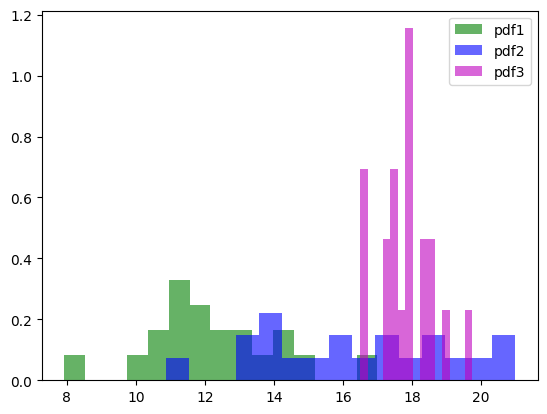

In [16]:
color = ["g","b","m","r","y"]
boundary = 12

fig = plt.figure()
plt.hist(d1, bins=15, color=color[0], density=True, alpha=0.6, label="pdf1")
plt.hist(d2, bins=15, color=color[1], density=True, alpha=0.6, label="pdf2")
plt.hist(d3, bins=15, color=color[2], density=True, alpha=0.6, label="pdf3")
# plt.ylim(0,0.45)
plt.legend()
plt.show()

# Población y Muestra

## Definiciones
- **Población:** Conjunto de objetos o individuos.
- **Muestra:** Grupo obtenido aleatoriamente.

## Tipos de muestreo
1. **Muestreo con reemplazo**  
2. **Muestreo sin reemplazo**  
3. **Muestreo aleatorio**  
4. **Muestreo estratificado**  
5. **Muestreo sesgado:** No representa a la población.

## Consideraciones sobre las muestras
- Es posible obtener **muestras representativas** de la población.
- También se pueden obtener **muestras sesgadas**, las cuales no representan adecuadamente a la población.

## Inferencia sobre las medias de las muestras
¿Cómo inferir las medias de las muestras a partir de los datos observados?

- **Intervalos de confianza**  
- **Pruebas de hipótesis**


# Bootstrapping

**Definición:**  
Remuestreo de los datos para obtener una muestra del estadístico que se calcula (por ejemplo, la media).

## Procedimiento
- Dada una muestra $x = x_1, x_2, x_3, x_4, x_5$, se seleccionan $N$ muestras aleatorias con reposición:
  - $x'_1 = x_1, x_1, x_2, x_1, x_5$
  - $x'_2 = x_2, x_6, x_2, x_1, x_5$
  - $x'_3 = x_5, x_1, x_5, x_1, x_5$
  - $x'_4 = x_2, x_3, x_1, x_1, x_5$
  - ...
  - ...

- Para cada remuestreo (bootstrap), se calcula el estadístico de interés (por ejemplo, la media, mediana, etc.):
  - $\theta_1$, $\theta_2$, $\theta_3$, ... $\theta_n$

- La estimación final $\langle \theta \rangle$ es la mejor aproximación a la media de la población, con su desviación estándar asociada.


In [8]:
# ! write a bootstraping python code for the next array [1,5,10,5,7,5,1,7,6]
# GPT 3 code,
# https://beta.openai.com/playground/p/default-friend-chat?model=text-davinci-001

import numpy as np

def bootstrap(data, n):
  bootstrap_sample = np.random.choice(data, size=n)
  return bootstrap_sample

In [9]:
def mean_stimador(d):
  m=[]
  s=[]
  for i in range(0,100):
    data = bootstrap(d, len(d))     # remuestreos
    m.append(np.mean(data))         # Medias de los bootstrap
    s.append(np.std(data))
  return m, s

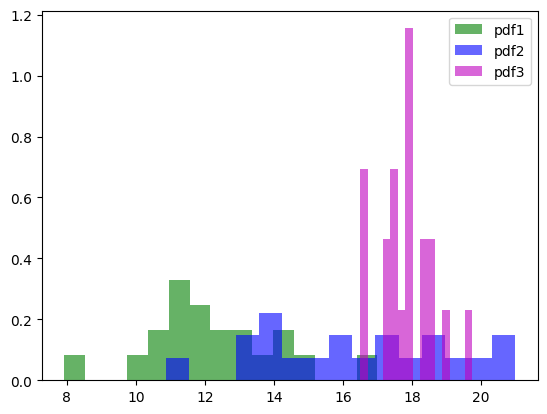

In [17]:
# plt.hist(d1)
# plt.hist(d2)
# plt.hist(d3)
fig

In [19]:
m_d1, s_d1 = mean_stimador(d1)
m_d2, s_d2 = mean_stimador(d2)
m_d3, s_d3 = mean_stimador(d3)

print('Estadísticos poblacionales por el método BOOTSTRAPPING')

print('\n* PDF1')
print('\tMedia poblacional estimada: ', np.mean(m_d1))
print('\tDesviación estándar poblacional estimada: ', np.mean(s_d1))

print('\n* PDF2')
print('\tMedia poblacional estimada: ', np.mean(m_d2))
print('\tDesviación estándar poblacional estimada: ', np.mean(s_d2))

print('\n* PDF3')
print('\tMedia poblacional estimada: ', np.mean(m_d3))
print('\tDesviación estándar poblacional estimada: ', np.mean(s_d3))

Estadísticos poblacionales por el método BOOTSTRAPPING

* PDF1
	Media poblacional estimada:  12.24096324256773
	Desviación estándar poblacional estimada:  1.8195871152121168

* PDF2
	Media poblacional estimada:  16.398633557545608
	Desviación estándar poblacional estimada:  2.5682372414031205
* PDF3
	Media poblacional estimada:  17.782021743343265
	Desviación estándar poblacional estimada:  0.7340324512196496


# [Teorema del limite central](https://es.wikipedia.org/wiki/Teorema_del_l%C3%ADmite_central)

El **Teorema del Límite Central (TLC)** es uno de los resultados más importantes de la estadística. De manera resumida, **establece** que, bajo ciertas condiciones, la **distribución de la suma (o promedio)** de variables aleatorias **independientes e idénticamente distribuidas** (i.i.d.) **se aproxima** a una **distribución normal** a medida que el **tamaño de la muestra** (número de variables) crece.

## Concepto clave

Si tomamos muchas variables aleatorias $(X_1, X_2, \ldots, X_n$) con:
- **misma distribución** (mismo tipo de distribución de probabilidad),
- **media** finita $(\mu$),
- **varianza** finita $(\sigma^2$),
- **independencia** entre ellas,

entonces, a medida que $(n$) aumenta, la **distribución** de la suma $(S_n = X_1 + X_2 + \ldots + X_n$) (o, equivalentemente, del **promedio** $(\overline{X} = \frac{1}{n} S_n$)) **tiende** a una **distribución normal** con media $(n \mu$) (si hablamos de la suma) o $(\mu$) (para el promedio) y varianza $(n \sigma^2$) (suma) o ($\frac{\sigma^2}{n})$ (promedio).

En notación, para el **promedio** \(\overline{X}\):

$$
\overline{X} = \frac{1}{n}(X_1 + X_2 + \cdots + X_n),
$$

el teorema dice que

$$
\sqrt{n}\left(\overline{X} - \mu\right) \;\; \xrightarrow{d} \;\; \mathcal{N}(0, \sigma^2)
$$

donde ($\xrightarrow{d}$) denota **convergencia en distribución** y ($\mathcal{N}(0,\sigma^2)$) es la **distribución normal** de media 0 y varianza ($\sigma^2$).

## Implicaciones y uso práctico

1. **Justifica la normalidad**: Explica por qué muchas **mediciones** de fenómenos naturales o experimentales terminan aproximándose a la **distribución normal**, incluso si los datos individuales **no** provienen de una normal (siempre que cumplan las condiciones básicas del TLC).

2. **Intervalos de confianza y test de hipótesis**: Permite, al trabajar con **promedios** o **estadísticos**, suponer la normalidad cuando el **tamaño de la muestra** es suficientemente grande, simplificando los **cálculos estadísticos** (por ejemplo, usando la distribución z).

3. **Ley de los grandes números** (relacionada): Mientras el TLC describe la **forma** de la distribución (aproximación a la normal), la Ley de los Grandes Números señala la **convergencia** del promedio ($\overline{X}$) a la media real ($\mu$) cuando ($n$) es grande.

## En qué condiciones se aplica

- Generalmente, **independencia** o al menos cierta forma de independencia (a veces basta con que estén “débilmente correlacionadas”).
- **Misma distribución** o que al menos las variables tengan la misma media y varianza. (Existen versiones **generalizadas** del TLC que permiten diferentes distribuciones mientras cumplan ciertas restricciones).
- **Media y varianza finitas**.

## Ejemplo intuitivo

Si tomas el **promedio** de los resultados de lanzar un dado muchas veces:
- Cada lanzamiento es una variable aleatoria entre 1 y 6.
- Su media $(\mu = 3.5$), varianza ($\sigma^2 = \frac{35}{12}$).
- Según aumenta el número de lanzamientos \(n\), la **distribución** de la media de los valores observados se aproxima a una **distribución normal** centrada en 3.5, aunque el dado inicialmente **no** es normal (es discreto).

## Conclusión

El **Teorema del Límite Central** explica por qué, en muchas situaciones, las **sumas** o **promedios** de variables aleatorias tienden a ser **normales** (aun si las variables originales no lo son), siempre que exista un **tamaño de muestra grande** y se cumplan ciertas condiciones de independencia y finitud de la media y varianza. Es la razón fundamental por la que la distribución normal es tan ubicua en estadística y en fenómenos naturales.

In [20]:
mlc = []

# Generamos mil medias de muestras de 100 datos
for i in range(0,1000):
  mlc.append(np.mean(f["ms1"].rvs(100)))

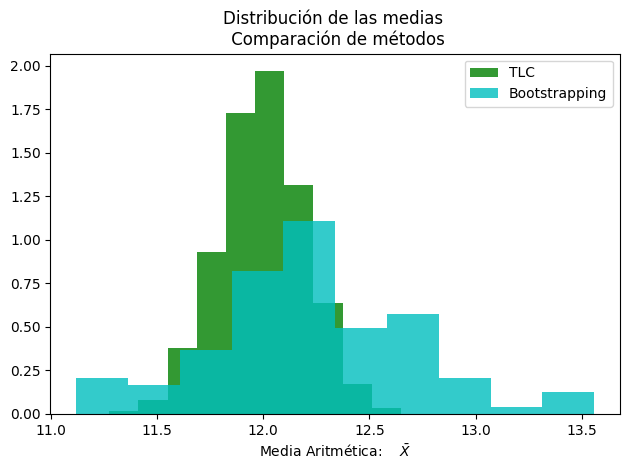

In [25]:
fig = plt.figure()
plt.title('Distribución de las medias \n Comparación de métodos')

# Media de diferentes distribuciones de los datos originales
plt.hist(mlc, density=True, color=color[0], alpha=0.8, label='TLC')

# Media de la distribuciones empleando bootstraping
plt.hist(m_d1, density=True, color='c', alpha=0.8, label='Bootstrapping')

plt.xlabel(r'Media Aritmética: $\quad \bar{X}$')

plt.legend()

fig.tight_layout()